In [16]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
load_dotenv()
from langgraph.checkpoint.memory import InMemorySaver

In [17]:
import os 
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API")

In [18]:
@tool
def search(location: str):
    """Call to get the weather information about a location"""
    query = f"weather in {location}"
    web_search_tool = TavilySearch(
        max_results = 1,
        include_answer = True
    )
    search_response = web_search_tool.invoke({"query" : query})
    return search_response

In [19]:
@tool 
def dummpy_post(post: str):
    """Call this function to post somthing on the website."""
    print("[Posted to Website]")
    return "Post Done!"

In [20]:
from langchain_ollama import ChatOllama

tools = [search]
tool_node = ToolNode(tools)

llm = ChatOllama(
    model = "qwen2.5:7b-instruct-q4_K_M",
    temperature = 0.4
)
# bind the llm with tools
llm_with_tools = llm.bind_tools(tools)

In [21]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    location: str # user given city 
    weather_data: str # current weather at that city
    report: str # llm generated report on the weather
    messages: Annotated[list , add_messages] # conversations 
    human_feedback: str # "approved" or any feedback for improvement

In [22]:
def agent(state: State) -> dict:
    """
    This node runs TWICE:
      Pass 1 -> LLM sees the location, decides to call search tool
      Pass 2 -> LLM sees the tool result, writes the weather report
    """
    # First visit
    if not state["messages"]:
        messages = [
            HumanMessage(
                content=(
                    f"Get the current weather for {state['location']} "
                    f"and write a concise, friendly weather report under 150 words."
                )
            )
        ]
    else:
        messages = state["messages"]

    response = llm_with_tools.invoke(messages)   
    return {"messages": [response]}

In [23]:
def rewrite_report(state: State) -> dict:
    """LLM rewrites the report incorporating the human's feedback."""
    print(f"Rewriting based on feedback: '{state['human_feedback']}'")
    prompt = f"""You are a weather reporter. Revise the weather report below 
based on the user's feedback. Keep it under 150 words, flowing prose.

Original report:
{state['report']}

User feedback:
{state['human_feedback']}
"""
    response = llm.invoke([HumanMessage(content=prompt)])
    return {
        "report": response.content,
        "messages": [HumanMessage(content=prompt), response],
        "human_feedback": ""   # reset so the next review is fresh
    }

In [24]:
def post_report(state: State) -> dict:
    result = dummpy_post.invoke(state["report"])
    print(f"{result}")
    return {}

In [25]:
def route_agent(state: State) -> str:
    """
    After agent runs, check the last message:
      - Has tool_calls?  -> execute them (go to ToolNode)
      - No tool_calls? -> LLM finished writing, move to human review
    """
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "human_review"

In [26]:
# human review node
def human_review(state: State)->dict:
    report = state["messages"][-1].content
    
    print("\n" + "="*60)
    print("WEATHER REPORT DRAFT:")
    print("="*30)
    print(report)
    print("="*30)
    
    feedback = interrupt(
      "Type  'approved'  to publish, or give feedback to rewrite:"
    )
    return {
        "report": report,
        "human_feedback": feedback
    }

In [27]:
def route_after_review(state: State):
    if state['human_feedback'].strip().lower() == "approved":
        return "post_report"
    else:
        return "rewrite_report"

In [28]:
checkpointer = InMemorySaver()

graph = StateGraph(State)

graph.add_node("agent" , agent)
graph.add_node("tools" , tool_node)
graph.add_node("human_review" , human_review)
graph.add_node("post_report", post_report)
graph.add_node("rewrite_report" , rewrite_report)

graph.add_edge(START , "agent")
# agent decies where to go(tool call or human review)
graph.add_conditional_edges(
    "agent", route_agent,
    {"tools": "tools", "human_review": "human_review"}
)
# if tool calls then add a edge between tools to agents
graph.add_edge("tools" , "agent")
# if human_review came then add a edge between human and agent
graph.add_conditional_edges(
    "human_review", route_after_review,
    {"post_report": "post_report", "rewrite_report": "rewrite_report"}
)
graph.add_edge("rewrite_report" , "human_review")
graph.add_edge("post_report" , END)

workflow = graph.compile(checkpointer = checkpointer)

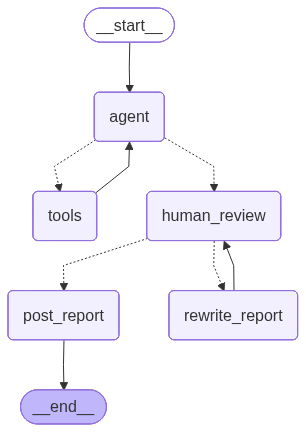

In [29]:
workflow

In [30]:
config = {"configurable": {"thread_id": "weather-session-1"}}

print("Starting graph...\n")

for event in workflow.stream({"location": "Dhaka, Bangladesh", "messages": []},config,stream_mode="values"):
    pass   

final = None 
# Human gives feedback 
while True: 
    user_input = input("\nYour response: ")   
    for event in workflow.stream(Command(resume=user_input), config, stream_mode="values"):
        final = event
    
    if final and not workflow.get_state(config).next:
        print("\nWorkflow complete!")
        break

Starting graph...


WEATHER REPORT DRAFT:
The current weather in Dhaka, Bangladesh is 80°F (29°C) with partly cloudy skies. The temperature feels like 107°F (42°C). There is no rain expected.

Here are some additional details:
- Last updated: 2026-05-25 15:15
- Wind speed: 16.6 mph from SSE direction
- Humidity: 52%
- Cloud cover: 31%

Would you like more information or a forecast for a different day?

WEATHER REPORT DRAFT:
The current weather in Dhaka, Bangladesh is 80°F (29°C) with partly cloudy skies. The temperature feels like 107°F (42°C). There is no rain expected.

Here are some additional details:
- Last updated: 2026-05-25 15:15
- Wind speed: 16.6 mph from SSE direction
- Humidity: 52%
- Cloud cover: 31%

Would you like more information or a forecast for a different day?
Rewriting based on feedback: 'make a 3 paragraphs: introduction, body and finally conclusions'

WEATHER REPORT DRAFT:
Good afternoon, Dhaka residents! As of 15:15 on May 25, the weather in Dhaka stands at 80°F

In [35]:
print(final['messages'][-1].content)

Good afternoon, Dhaka residents! As of 15:15 on May 25, the weather in Dhaka stands at 80°F (29°C) with partly cloudy skies, making it feel like a more intense 107°F (42°C). The day promises clear blue skies interspersed with patches of cloud, providing some relief from the heat. With a steady wind speed of 16.6 mph coming from the southeast-southeast direction and a comfortable humidity level at 52%, conditions are ideal for outdoor activities.

In terms of the forecast, there is no immediate expectation of rain, ensuring that the current pleasant weather will continue. However, it’s always wise to keep an eye on updates as weather patterns can change quickly in Dhaka. For those planning events or outdoor activities, staying informed about any sudden changes will help ensure a smooth and enjoyable experience.

That concludes today's weather update for Dhaka. Should you need more detailed information or wish to check the forecast for another day, feel free to ask!
